<a href="https://colab.research.google.com/github/aviverma02/credit-card-fraud-detection/blob/main/Credit_Card_Fraud_Detection_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [4]:
df = pd.read_csv("creditcard.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print("Dataset Information")
print("-------------------")

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Information
-------------------
Number of Rows: 284807
Number of Columns: 31

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [6]:
print("Missing Values in Each Column:")
print("--------------------------------")

missing_values = df.isnull().sum()

display(missing_values[missing_values > 0])

Missing Values in Each Column:
--------------------------------


,0


In [7]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Transactions:", duplicate_count)

Number of Duplicate Transactions: 1081


In [8]:
print("Transaction Class Distribution")
print("-------------------------------")

class_counts = df["Class"].value_counts()

print(class_counts)

print("\nPercentage Distribution:")
class_percentage = df["Class"].value_counts(normalize=True) * 100

print(class_percentage.round(4))

Transaction Class Distribution
-------------------------------
Class
0    284315
1       492
Name: count, dtype: int64

Percentage Distribution:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


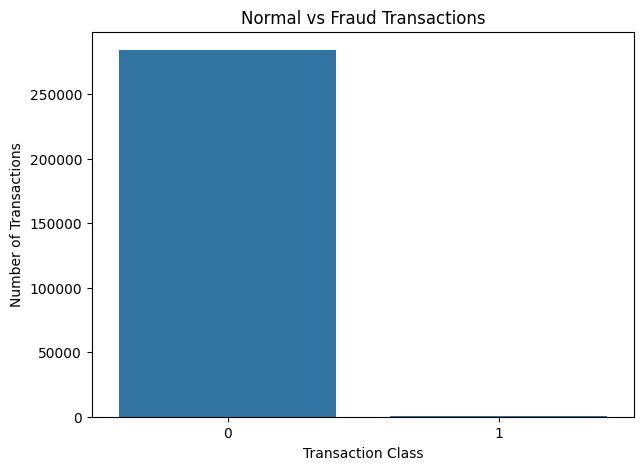

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Normal vs Fraud Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

In [10]:
# Separate features and target

X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (284807, 30)
Target shape: (284807,)

Feature columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (227845, 30)
Testing data: (56962, 30)

Training target distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing target distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [12]:
# Calculate scale_pos_weight for imbalanced dataset

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Normal transactions:", negative)
print("Fraud transactions:", positive)
print("Scale Pos Weight:", scale_pos_weight)

Normal transactions: 227451
Fraud transactions: 394
Scale Pos Weight: 577.2868020304569


In [13]:
# Create XGBoost model

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

print("XGBoost model created successfully!")

XGBoost model created successfully!


In [14]:
# Train the XGBoost model

print("Training XGBoost model...")

model.fit(
    X_train,
    y_train
)

print("Model training completed!")

Training XGBoost model...
Model training completed!


In [15]:
# Make predictions on test data

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 56962


In [16]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

print("Model Evaluation")
print("-----------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

Model Evaluation
-----------------
Accuracy : 0.9995
Precision: 0.8817
Recall   : 0.8367
F1 Score : 0.8586
ROC-AUC  : 0.9795
PR-AUC   : 0.8826


Confusion Matrix:
[[56853    11]
 [   16    82]]


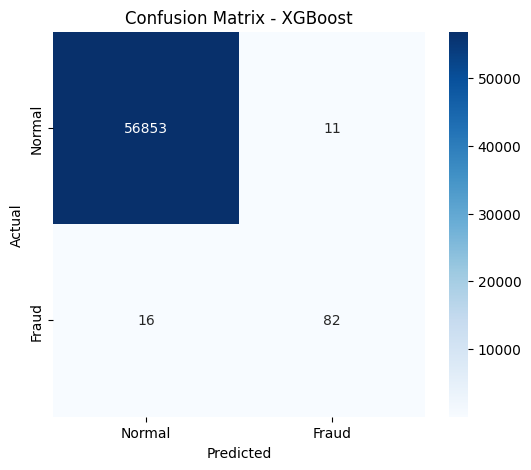

In [17]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [18]:
# Detailed Classification Report

print("Classification Report:")
print("-----------------------")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Fraud"]
    )
)

Classification Report:
-----------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



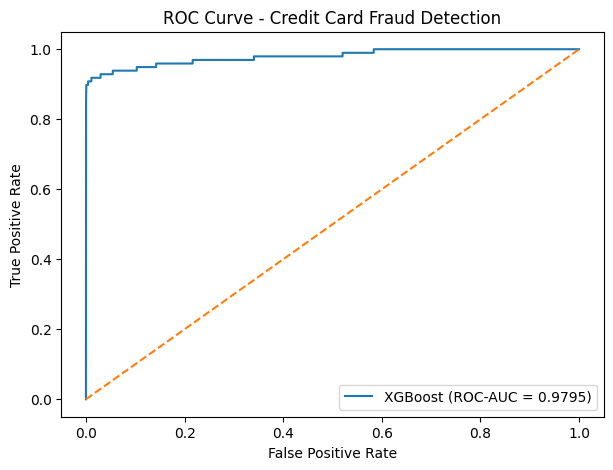

In [19]:
# ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (ROC-AUC = {roc_auc:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - Credit Card Fraud Detection")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

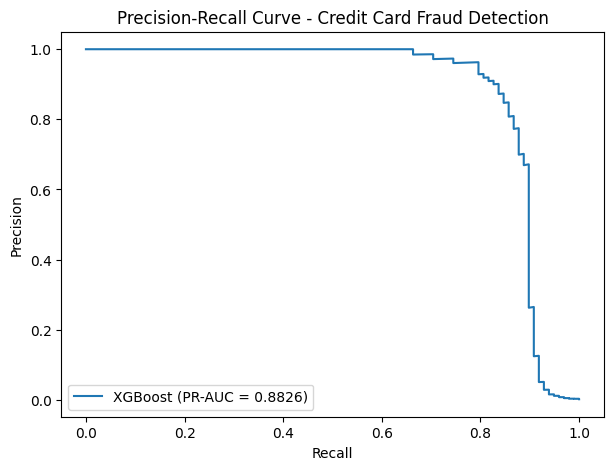

In [20]:
# Precision-Recall Curve

precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    y_pred_proba
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_values,
    precision_values,
    label=f"XGBoost (PR-AUC = {pr_auc:.4f})"
)

plt.title("Precision-Recall Curve - Credit Card Fraud Detection")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()
plt.show()

In [21]:
# Feature Importance

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 15 Important Features:")
print(feature_importance.head(15))

Top 15 Important Features:
V14       0.542006
V4        0.066436
V10       0.055420
V12       0.034997
Amount    0.025401
V8        0.020477
V20       0.020151
V26       0.019073
V13       0.016891
V17       0.015051
V7        0.014555
V22       0.013348
V16       0.012749
V19       0.012737
V3        0.012621
dtype: float32


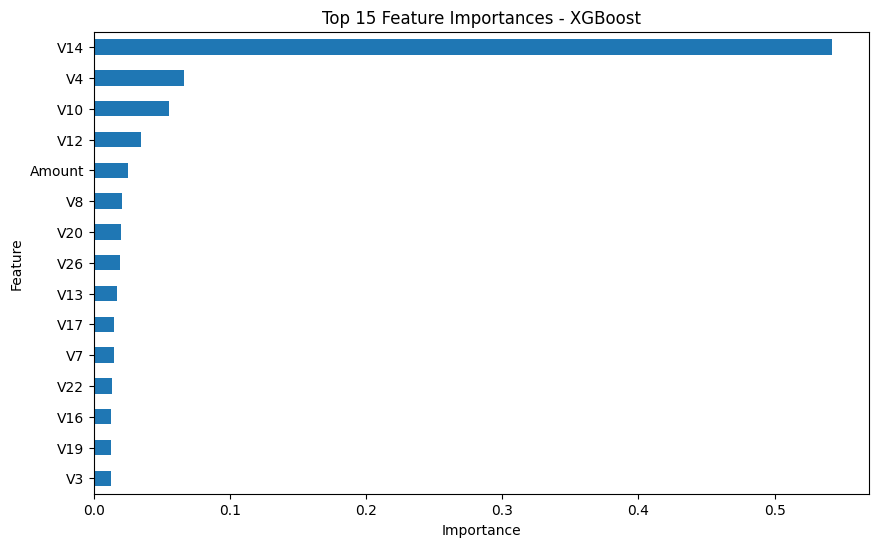

In [22]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [23]:
# False Positives and False Negatives

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("Confusion Matrix Analysis")
print("-------------------------")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Confusion Matrix Analysis
-------------------------
True Negatives : 56853
False Positives: 11
False Negatives: 16
True Positives : 82


In [24]:
import joblib

joblib.dump(model, "credit_card_fraud_xgboost.pkl")

print("Model saved successfully!")

Model saved successfully!


In [25]:
from google.colab import files

files.download("credit_card_fraud_xgboost.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>